In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [4]:
df=pd.read_csv("/content/CarPrice_Assignment.csv")

In [5]:
df.shape

(205, 26)

In [6]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [7]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [8]:
num_col=df.select_dtypes(exclude='object')
num_col.columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [9]:
colsDrp=['symboling','carheight','stroke','compressionratio','peakrpm','CarName']
df.drop(columns=colsDrp,inplace=True)

In [10]:
cat_col=df.select_dtypes(include=['object']).columns
df[cat_col].nunique()

,0
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
enginetype,7
cylindernumber,7
fuelsystem,8


In [11]:
df = pd.get_dummies(columns = ['fueltype', 'aspiration', 'doornumber', 'drivewheel', 'enginelocation'], data = df, drop_first = True)

In [12]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [13]:
encoder=OrdinalEncoder()
for i in df.select_dtypes(include='object').columns:
    df[i]=encoder.fit_transform(df[[i]])

In [14]:
X=df.drop('price',axis=1) #feature columns
y=df['price'] #Label column

In [15]:
X.shape

(205, 20)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=20)

In [18]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LinearRegression, Ridge

In [20]:
#Multiple linear regression

In [21]:
rgsr=LinearRegression()

In [22]:
model=rgsr.fit(X_train_scaled,y_train)

In [23]:
y_pred=model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MLR (All features)")
print(f"Mean absolute error={mae:.2f}")
print(f"Root mean squared error={rmse:.2f}")
print(f"R squared score:{r2*100:.2f}%\n")

MLR (All features)
Mean absolute error=1970.16
Root mean squared error=2421.17
R squared score:83.18%



In [26]:
#visualisation

In [27]:
#initialise visualisation model and import
from yellowbrick.regressor import PredictionError

In [28]:
#Model 1
visualizer = PredictionError(rgsr)

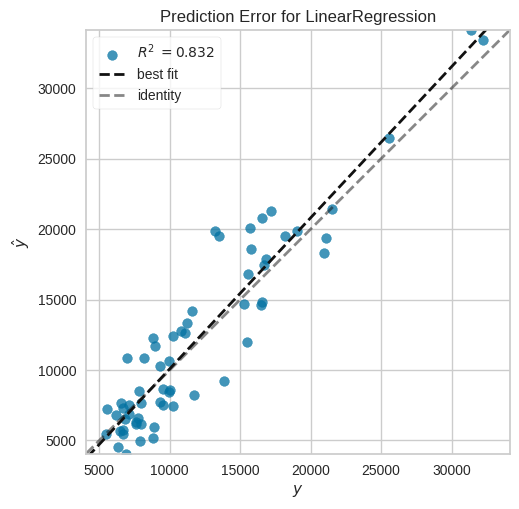

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [29]:
#fit the training data to visualiser
visualizer.fit(X_train_scaled,y_train)

#evaluate model on test data
visualizer.score(X_test_scaled,y_test)

#finalize and render figure
visualizer.show()

In [30]:
#model 2-Feature selection (SFS)

In [31]:
rgsr=LinearRegression()

In [32]:
from sklearn.feature_selection import SequentialFeatureSelector as sfs

In [33]:
selector=sfs(rgsr,n_features_to_select=5,direction='backward')
selector=selector.fit(X_train_scaled,y_train)

#get the names
selected_features=list(X.columns[selector.get_support()] )
print(selected_features)

#slice the orignal data frame
X_train_selected=X_train[selected_features]
X_test_selected=X_test[selected_features]

#Re scale
scaler_new=StandardScaler()
X_train_sel_scaled=scaler_new.fit_transform(X_train_selected)
X_test_sel_scaled=scaler_new.transform(X_test_selected)

#Fit the model
model=rgsr.fit(X_train_sel_scaled,y_train)

['car_ID', 'wheelbase', 'enginesize', 'horsepower', 'enginelocation_rear']


In [34]:
y_pred_sfs=model.predict(X_test_sel_scaled)

In [35]:
mae_sfs=mean_absolute_error(y_test,y_pred_sfs)
mse_sfs=mean_squared_error(y_test,y_pred_sfs)
rmse_sfs=np.sqrt(mse_sfs)
r2_sfs=r2_score(y_test,y_pred_sfs)

print("MLR (SFS selected features)")
print(f"Selected features: {list(X.columns[selector.get_support()])}")
print(f"Mean absolute error={mae:.2f}")
print(f"Root mean squared error={rmse:.2f}")
print(f"R squared score:{r2*100:.2f}%\n")

MLR (SFS selected features)
Selected features: ['car_ID', 'wheelbase', 'enginesize', 'horsepower', 'enginelocation_rear']
Mean absolute error=1970.16
Root mean squared error=2421.17
R squared score:83.18%



**First code uses selected scaled features, while second code uses all scaled features for training and evaluation.**

**MODEL 3**

**Ridge regression**

In [36]:
rgsr = Ridge(alpha=50 , max_iter=100 , tol=0.1)
model=rgsr.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

In [37]:
mae_r = mean_absolute_error(y_test,y_pred)
mse_r = mean_squared_error(y_test,y_pred)
rmse_r = np.sqrt(mse_r)
r2_r = r2_score(y_test,y_pred)

In [38]:
print("---Ridge Regression----")
print(f"Mean absolute error={mae_r:.2f}")
print(f"Root mean squared error={rmse_r:.2f}")
print(f"R squared score:{r2_r*100:.2f}%\n")

---Ridge Regression----
Mean absolute error=1663.85
Root mean squared error=2160.96
R squared score:86.60%



In [39]:
visualizer = PredictionError(rgsr)

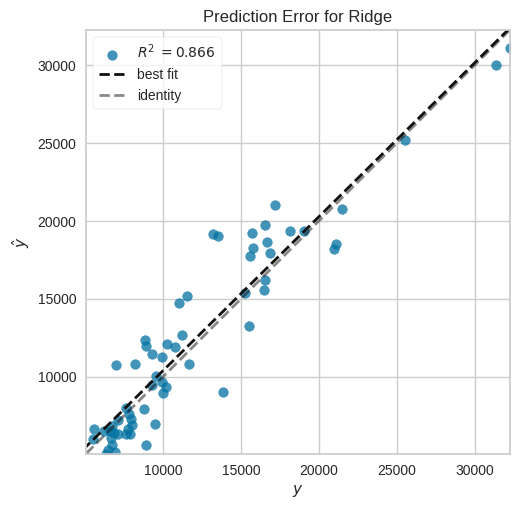

<Axes: title={'center': 'Prediction Error for Ridge'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [40]:
#Fit the training data to th visualizer
# visualizer.fit(X_train_scaled  , y_train)

visualizer = PredictionError(rgsr)
visualizer.fit(X_train_scaled, y_train)
visualizer.score(X_test_scaled, y_test) # Optional but recommended
visualizer.show()

In [41]:
#Evaluate model on test data
visualizer.score(X_test_scaled, y_test)
#finalize and render th fig
visualizer.show()

<Axes: title={'center': 'Prediction Error for Ridge'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [42]:
# Polynomial regresion
from sklearn.preprocessing import PolynomialFeatures

In [43]:
X = df[['enginesize' , 'horsepower' , 'curbweight' , 'highwaympg']]
Y = df['price']

In [44]:
#2 train test split
X_train , X_test , Y_train , Y_test = train_test_split(X ,y , test_size=0.3, random_state=20 )

In [45]:
#3 Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#generte polynomial feature (degree 2)
poly = PolynomialFeatures(degree=2 , include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [47]:
#5 Fit the linear model on the polynomial Feature

rgsr = LinearRegression()
model = rgsr.fit(X_train_poly , Y_train)

In [48]:
#6 Predict value

y_pred_p = model.predict(X_test_poly)

mae_p = mean_absolute_error(y_test,y_pred_p)
mse_p = mean_squared_error(y_test,y_pred_p)
rmse_p = np.sqrt(mse_p)
r2_p = r2_score(y_test,y_pred_p)

print("---Polynomial Regression----")
print(f"Mean absolute error={mae_p:.2f}")
print(f"Root mean squared error={rmse_p:.2f}")
print(f"R squared score:{r2_p*100:.2f}%\n")

---Polynomial Regression----
Mean absolute error=2043.38
Root mean squared error=2707.26
R squared score:78.97%



**Polynomial regression visualization**

In [49]:
feature_idx = 1
feature_name = X.columns[feature_idx]

x_range = np.linspace(X_test.iloc[:, feature_idx].min(), X_test.iloc[:, feature_idx].max(), 100)

dummy_X = pd.DataFrame(np.tile(X_test.mean().values, (100, 1)), columns = X_test.columns)
dummy_X.iloc[:, feature_idx] = x_range

dummy_X_scaled = scaler.transform(dummy_X)
dummy_X_poly = poly.transform(dummy_X_scaled)

curve_preds = model.predict(dummy_X_poly)

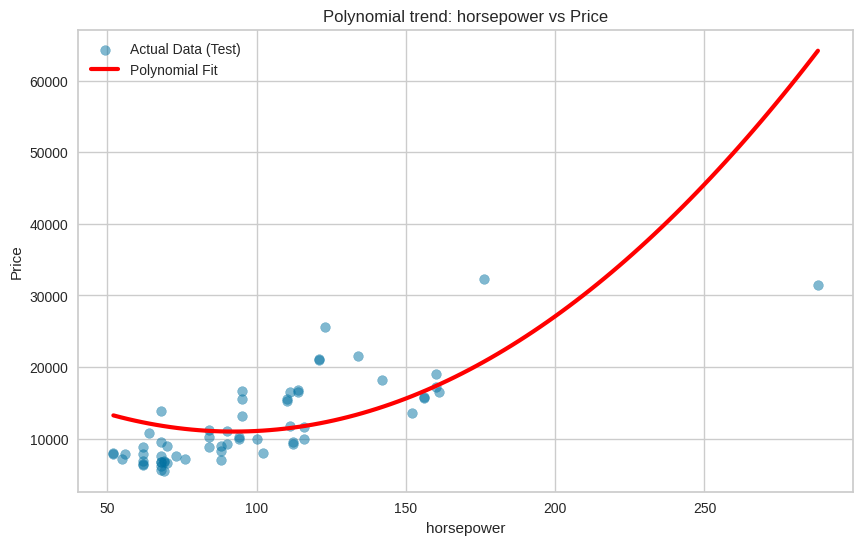

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, feature_idx], y_test, alpha=.5, label='Actual Data (Test)')
plt.plot(x_range, curve_preds, color='red', linewidth=3, label='Polynomial Fit')
plt.xlabel(feature_name) # Fixed the double call here
plt.ylabel('Price')
plt.title(f'Polynomial trend: {feature_name} vs Price') # Fixed 'tile' to 'title'
plt.legend()
plt.show()